# Upload data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
centros = pd.read_csv("/content/uc3m-centros-2023-24 (1).xlsx - Sheet1.csv")

centros.head()

,curso_academico,cod_universidad,des_universidad,cod_centro,des_centro,cod_municipio,des_municipio,cod_campus,des_campus,cod_tipo_centro,des_tipo_centro,cod_naturaleza_centro,des_naturaleza_centro,cod_situacion_centro,des_situacion_centro,fecha_desde_situacion_centro,latitude,longitude
0,2023-24,36,Universidad Carlos III de Madrid,28041822,Facultad de Ciencias Sociales y Jurídicas. (Ge...,28065,GETAFE,3602,Getafe,C1,Centro Propio,1,Público,1,Activo,20130701,40.31570,-3.72570
1,2023-24,36,Universidad Carlos III de Madrid,28042292,Escuela Politécnica Superior. (Leganés),28074,LEGANÉS,3601,Leganés,C1,Centro Propio,1,Público,1,Activo,20130701,40.33184,-3.76521
2,2023-24,36,Universidad Carlos III de Madrid,28048385,"Facultad de Humanidades, Comunicación y Docume...",28065,GETAFE,3602,Getafe,C1,Centro Propio,1,Público,1,Activo,20130701,40.31876,-3.72740
3,2023-24,36,Universidad Carlos III de Madrid,28050461,Facultad de Ciencias Sociales y Jurídicas (Col...,28044,COLMENAREJO,3603,Colmenarejo,C1,Centro Propio,1,Público,1,Activo,20130701,40.54344,-4.01327
4,2023-24,36,Universidad Carlos III de Madrid,28050471,"Facultad de Humanidades, Comunicación y Docume...",28044,COLMENAREJO,3603,Colmenarejo,C1,Centro Propio,1,Público,1,Activo,20130701,40.54241,-4.01269


# Inspect structure

In [ ]:
print("Shape:", centros.shape)

print("\nColumns:")
print(centros.columns)

print("\nMissing values:")
print(centros.isnull().sum())

Shape: (16, 18)

Columns:
Index(['curso_academico', 'cod_universidad', 'des_universidad', 'cod_centro',
       'des_centro', 'cod_municipio', 'des_municipio', 'cod_campus',
       'des_campus', 'cod_tipo_centro', 'des_tipo_centro',
       'cod_naturaleza_centro', 'des_naturaleza_centro',
       'cod_situacion_centro', 'des_situacion_centro',
       'fecha_desde_situacion_centro', 'latitude', 'longitude'],
      dtype='object')

Missing values:
curso_academico                 0
cod_universidad                 0
des_universidad                 0
cod_centro                      0
des_centro                      0
cod_municipio                   0
des_municipio                   0
cod_campus                      0
des_campus                      0
cod_tipo_centro                 0
des_tipo_centro                 0
cod_naturaleza_centro           0
des_naturaleza_centro           0
cod_situacion_centro            0
des_situacion_centro            0
fecha_desde_situacion_centro    0
latitude

There are no missing values, so no need for imputation or removing rows

In [ ]:
centros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   curso_academico               16 non-null     object 
 1   cod_universidad               16 non-null     int64  
 2   des_universidad               16 non-null     object 
 3   cod_centro                    16 non-null     int64  
 4   des_centro                    16 non-null     object 
 5   cod_municipio                 16 non-null     int64  
 6   des_municipio                 16 non-null     object 
 7   cod_campus                    16 non-null     int64  
 8   des_campus                    16 non-null     object 
 9   cod_tipo_centro               16 non-null     object 
 10  des_tipo_centro               16 non-null     object 
 11  cod_naturaleza_centro         16 non-null     int64  
 12  des_naturaleza_centro         16 non-null     object 
 13  cod_sit

# Standardizing campus identifiers

In [ ]:
campus_map = {
    3601: 1,  # Leganés
    3602: 2,  # Getafe
    3603: 3,  # Colmenarejo
    3604: 4,  # Madrid
    3605: 5   # Aranjuez
}

centros["campus_id"] = centros["cod_campus"].map(campus_map)

centros["campus_id"] = centros["campus_id"].fillna(6)

centros[["cod_campus", "des_campus", "campus_id"]].head()

,cod_campus,des_campus,campus_id
0,3602,Getafe,2
1,3601,Leganés,1
2,3602,Getafe,2
3,3603,Colmenarejo,3
4,3603,Colmenarejo,3


# Relevant columns

In [ ]:
cols_keep = [
    "cod_centro",
    "des_centro",
    "campus_id",
    "des_campus",
    "des_tipo_centro",
    "des_naturaleza_centro",
    "des_situacion_centro",
]

centros_clean = centros[cols_keep].copy()

centros_clean.head()

,cod_centro,des_centro,campus_id,des_campus,des_tipo_centro,des_naturaleza_centro,des_situacion_centro
0,28041822,Facultad de Ciencias Sociales y Jurídicas. (Ge...,2,Getafe,Centro Propio,Público,Activo
1,28042292,Escuela Politécnica Superior. (Leganés),1,Leganés,Centro Propio,Público,Activo
2,28048385,"Facultad de Humanidades, Comunicación y Docume...",2,Getafe,Centro Propio,Público,Activo
3,28050461,Facultad de Ciencias Sociales y Jurídicas (Col...,3,Colmenarejo,Centro Propio,Público,Activo
4,28050471,"Facultad de Humanidades, Comunicación y Docume...",3,Colmenarejo,Centro Propio,Público,Activo


# Categorical analysis

### Center distribution

In [ ]:
centros_clean["des_centro"].value_counts()

,count
des_centro,
Centro de Postgrado,2
Escuela de Doctorado,2
"Facultad de Humanidades, Comunicación y Documentación. (Getafe)",1
Facultad de Ciencias Sociales y Jurídicas (Colmenarejo),1
Facultad de Ciencias Sociales y Jurídicas. (Getafe),1
Escuela Politécnica Superior. (Leganés),1
Escuela Politécnica Superior (Colmenarejo),1
"Facultad de Humanidades, Comunicación y Documentación (Colmenarejo)",1
Centro Universitario Guardia Civil,1


### Campus distribution

In [ ]:
centros_clean["des_campus"].value_counts()

,count
des_campus,
Getafe,8
Leganés,3
Colmenarejo,3
Aranjuez,1
Madrid- Puerta de Toledo,1


### Type of center distribution

In [ ]:
centros_clean["des_tipo_centro"].value_counts()

,count
des_tipo_centro,
Centro Propio,11
Instituto universitario de investigación,4
Centro adscrito,1


# Visualisations

### Center distribution

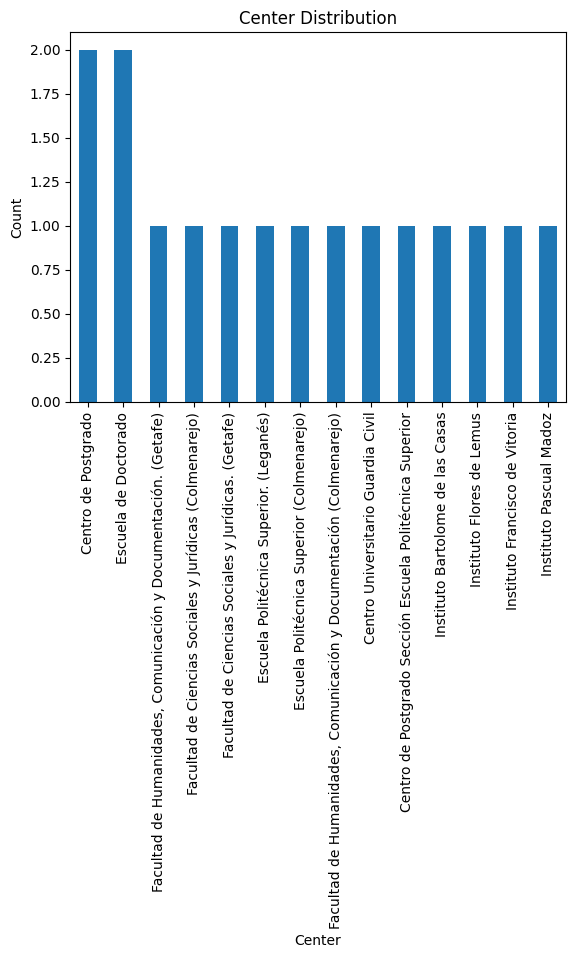

In [ ]:
centros_clean["des_centro"].value_counts().plot(kind="bar")

plt.title("Center Distribution")
plt.xlabel("Center")
plt.ylabel("Count")
plt.show()

### Campus distribution

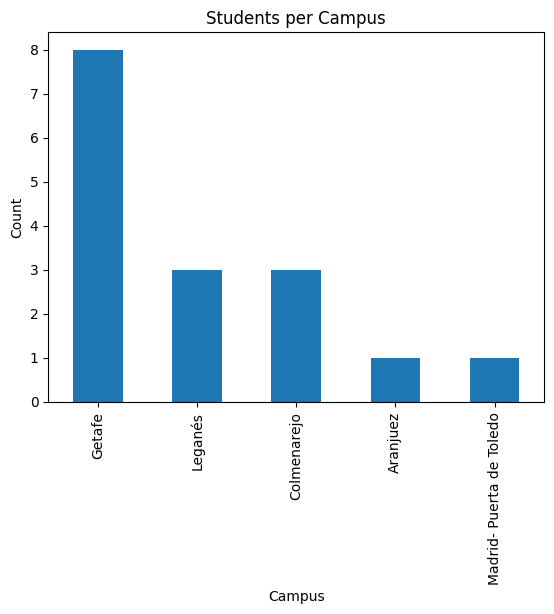

In [ ]:
centros_clean["des_campus"].value_counts().plot(kind="bar")

plt.title("Students per Campus")
plt.xlabel("Campus")
plt.ylabel("Count")
plt.show()

# Export cleaned dataset

In [ ]:
centros_clean.to_csv("centros.csv", index=False)